# IBCS scaling rules – YOLO notebook based on my current repo

This notebook is built around the GitHub repo structure:

```text
IBCS-scaling-rules-check-YOLO/
├── Dataset/
│   ├── Compliant/
│   └── Not Compliant/
└── yolo.ipynb
```

The current repo dataset is set up for **classification**, not full object detection.  
That means the model can already learn to classify a whole dashboard image as:

- `compliant`
- `not_compliant`

but it cannot yet draw bounding boxes around separate dashboard parts unless a new **annotated detection dataset** is added.

This notebook therefore does two things:

1. it explains **what YOLO is** and how it works in a way I can present clearly
2. it trains a **YOLO classification model** on the data already present in the repo

At the end, I also explain what would need to change to extend this into a detection pipeline with bounding boxes, OCR and IBCS rule checking.


## 1. What is YOLO?

**YOLO** stands for **You Only Look Once**.  
It is a computer vision model that can analyse an image in one forward pass.

In general, YOLO is best known for **object detection**:
- finding **what** is in an image
- and **where** it is located using bounding boxes

However, the Ultralytics YOLO framework also supports **classification** models.  
That is the version used in this notebook, because the current repo data only contains two folders with class labels and no bounding box annotations.

So in this notebook:

- the **framework** is YOLO
- the **task** is classification
- the **input** is a dashboard image
- the **output** is either `compliant` or `not_compliant`

That makes this a good first step before moving to full dashboard-part detection.


## 2. Why this repo currently uses classification instead of detection

The repo data is organised as:

```text
Dataset/
├── Compliant/
└── Not Compliant/
```

This structure tells the model only **which class the full image belongs to**.  
It does **not** tell the model where the y-axis is, where the tick labels are, or where the title is.

So the current model learns from the whole dashboard image and predicts one label for the full image.

### Important difference

**Classification**
- one label for the whole image

**Detection**
- multiple labels inside one image
- each label also gets a bounding box

Because the current repo only has image-level labels, classification is the correct starting point.


## 3. Does this create a new dataset?

This is an important question, and the answer is:

### Yes, but only as a reorganised version of the current data

The original repo dataset stays the same:

```text
Dataset/
├── Compliant/
└── Not Compliant/
```

In this notebook I create a new folder called `dataset_split/` with:

```text
dataset_split/
├── train/
│   ├── compliant/
│   └── not_compliant/
├── val/
│   ├── compliant/
│   └── not_compliant/
└── test/
    ├── compliant/
    └── not_compliant/
```

So it is **not a completely different dataset from scratch**.  
It is the **same images**, copied into train/validation/test folders so the model can be trained and evaluated properly.

### Later, for full object detection
If I want YOLO to detect dashboard parts with bounding boxes, then I would need to make a **new annotated detection dataset**.  
That means the same images can still be reused, but I must add bounding box labels for classes such as:

- `chart_area`
- `x_axis`
- `y_axis`
- `tick_label`
- `chart_title`
- `legend`
- `scale_indicator`


## 4. How the model makes decisions

The model does **not** understand IBCS rules directly.

Instead, it learns **visual patterns** from the training images.

For example, the model may learn that compliant dashboards often share patterns such as:

- more consistent visual structure
- cleaner scaling and spacing
- less misleading layout choices

And it may learn that not compliant dashboards often contain other recurring visual patterns.

### So what is the model really doing?
It receives an image as pixels, converts that image into internal feature maps, and gradually learns which visual features help separate the two classes.

That means the model is making a decision based on:
- visual texture
- shapes
- layout patterns
- contrast
- recurring structural image features

It is **not** reading a written rulebook.
That is why classification can tell me **whether** an image looks compliant, but not yet **which exact dashboard element** caused the problem.


## 5. Visual summary of the current workflow

```text
Dashboard image
      ↓
YOLO classification model
      ↓
Feature extraction from visual patterns
      ↓
Class probabilities
      ↓
Prediction: compliant / not_compliant
```

### What happens later in a full pipeline?
A more advanced pipeline would look like this:

```text
Dashboard image
      ↓
YOLO detection model
      ↓
Bounding boxes for dashboard parts
      ↓
OCR reads scale text and labels
      ↓
Rule-based checks compare scales using IBCS logic
      ↓
Final output: compliant / not compliant + explanation
```

So this notebook covers the **first stage** based on the data already in the repo.


In [ ]:
# Install only if needed
# !pip install -U ultralytics scikit-learn matplotlib pandas pillow seaborn


In [2]:
from pathlib import Path
import random
import shutil
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from ultralytics import YOLO


## 6. Paths and training settings

This notebook assumes it is placed in the root of the repo.


In [18]:
# Adjust this only if your notebook is not in the repo root
PROJECT_ROOT = Path.cwd()

DATASET_DIR = PROJECT_ROOT / "Dataset"
COMPLIANT_DIR = DATASET_DIR / "Compliant"
NON_COMPLIANT_DIR = DATASET_DIR / "Not Compliant"

SPLIT_DIR = PROJECT_ROOT / "dataset_split"

MODEL_NAME = "yolov8n-cls.pt"
IMG_SIZE = 640
EPOCHS = 20
BATCH = 16
DEVICE = "cpu"      # change to "cpu" if you do not have a GPU
WORKERS = 2
SEED = 42

print("Project root:", PROJECT_ROOT)
print("Dataset dir exists:", DATASET_DIR.exists())
print("Compliant dir exists:", COMPLIANT_DIR.exists())
print("Not Compliant dir exists:", NON_COMPLIANT_DIR.exists())


Project root: c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO
Dataset dir exists: True
Compliant dir exists: True
Not Compliant dir exists: True


## 7. Inspect the current dataset


In [19]:
def get_images(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    if not Path(folder).exists():
        return []
    return [p for p in Path(folder).glob("*") if p.suffix.lower() in exts]

compliant_images = get_images(COMPLIANT_DIR)
non_compliant_images = get_images(NON_COMPLIANT_DIR)

print("Compliant:", len(compliant_images))
print("Not Compliant:", len(non_compliant_images))
print("Total:", len(compliant_images) + len(non_compliant_images))


Compliant: 140
Not Compliant: 251
Total: 391


In [6]:
class_counts = pd.DataFrame({
    "class": ["compliant", "not_compliant"],
    "count": [len(compliant_images), len(non_compliant_images)]
})

class_counts


,class,count
0,compliant,140
1,not_compliant,251


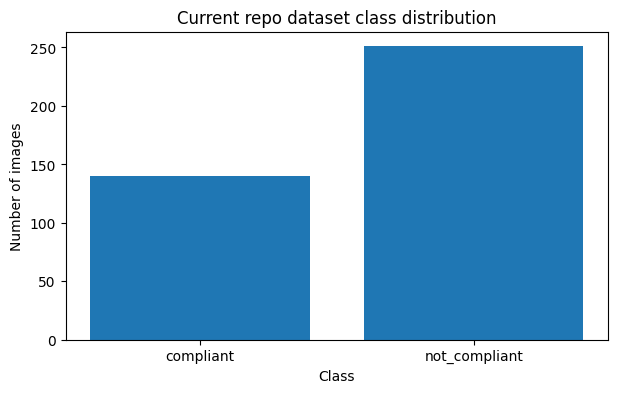

In [7]:
plt.figure(figsize=(7, 4))
plt.bar(class_counts["class"], class_counts["count"])
plt.title("Current repo dataset class distribution")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.show()


### Why this chart matters

Before training, I first check whether both classes are represented.  
If one class has far more images than the other, the model can become biased toward the larger class.

So this is one of the first visual checks I use before training starts.


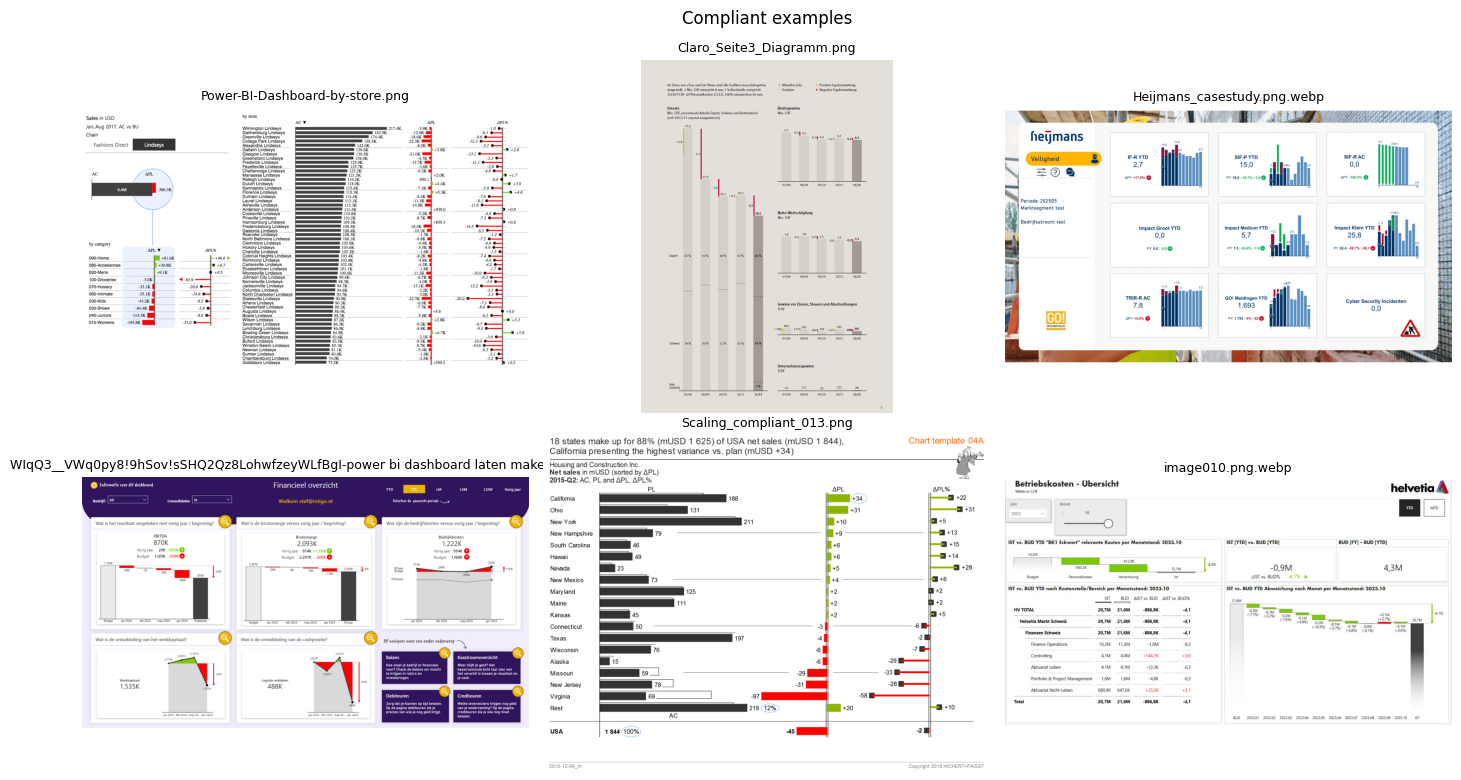

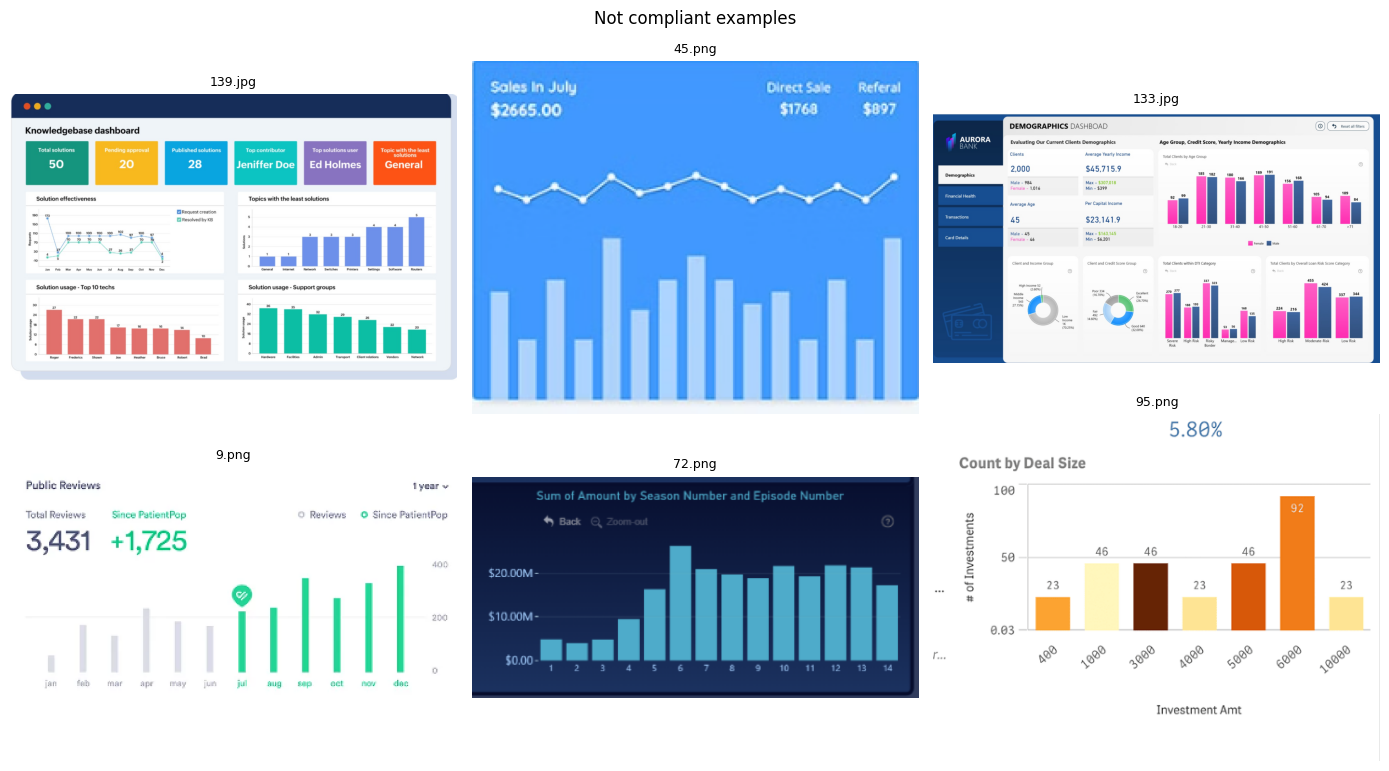

In [8]:
def preview_images(image_list, title, n=6):
    if not image_list:
        print(f"No images found for {title}")
        return

    sample = random.sample(image_list, min(n, len(image_list)))

    plt.figure(figsize=(14, 8))
    for i, img_path in enumerate(sample, start=1):
        img = Image.open(img_path)
        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(img_path.name, fontsize=9)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

preview_images(compliant_images, "Compliant examples")
preview_images(non_compliant_images, "Not compliant examples")


### Why I visualise examples before training

This helps me check:
- whether the images load correctly
- whether the folders really contain the right type of dashboards
- whether there are strange files, duplicates or obvious mistakes

So this is part of the **domain and data understanding** step.


## 8. Create a train / validation / test split

YOLO classification expects images grouped by class inside the split folders.

This is the point where a **new split dataset** is created.  
Again, this is **not a brand-new original dataset**, but a structured copy of the current repo images.


In [12]:
def prepare_split_dirs(base_dir):
    for split in ["train", "val", "test"]:
        for cls in ["compliant", "not_compliant"]:
            (base_dir / split / cls).mkdir(parents=True, exist_ok=True)

def clear_split_dir(base_dir):
    if base_dir.exists():
        shutil.rmtree(base_dir)
    base_dir.mkdir(parents=True, exist_ok=True)

def split_and_copy(files, out_base, class_name, train_ratio=0.7, val_ratio=0.15, seed=42):
    random.seed(seed)
    files = files.copy()
    random.shuffle(files)

    n = len(files)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_files = files[:n_train]
    val_files = files[n_train:n_train + n_val]
    test_files = files[n_train + n_val:]

    split_map = {
        "train": train_files,
        "val": val_files,
        "test": test_files,
    }

    for split, split_files in split_map.items():
        for file_path in split_files:
            dst = out_base / split / class_name / file_path.name
            shutil.copy2(file_path, dst)

    return {k: len(v) for k, v in split_map.items()}

clear_split_dir(SPLIT_DIR)
prepare_split_dirs(SPLIT_DIR)

stats_compliant = split_and_copy(compliant_images, SPLIT_DIR, "compliant", seed=SEED)
stats_non_compliant = split_and_copy(non_compliant_images, SPLIT_DIR, "not_compliant", seed=SEED)

print("Compliant split:", stats_compliant)
print("Not compliant split:", stats_non_compliant)


Compliant split: {'train': 98, 'val': 21, 'test': 21}
Not compliant split: {'train': 175, 'val': 37, 'test': 39}


In [13]:
split_summary = []
for split in ["train", "val", "test"]:
    for cls in ["compliant", "not_compliant"]:
        count = len(list((SPLIT_DIR / split / cls).glob("*")))
        split_summary.append({"split": split, "class": cls, "count": count})

split_df = pd.DataFrame(split_summary)
split_df


,split,class,count
0,train,compliant,98
1,train,not_compliant,175
2,val,compliant,21
3,val,not_compliant,37
4,test,compliant,21
5,test,not_compliant,39


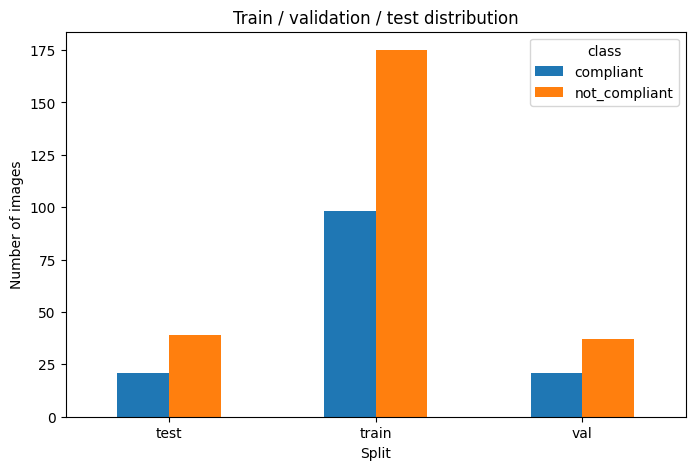

In [14]:
pivot_df = split_df.pivot(index="split", columns="class", values="count").fillna(0)

pivot_df.plot(kind="bar", figsize=(8, 5))
plt.title("Train / validation / test distribution")
plt.xlabel("Split")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.show()


### Why the split matters

The model learns on the **training set**, is monitored on the **validation set**, and is judged on the **test set**.

That is important because otherwise I might accidentally evaluate the model on images it has already seen during training.


## 9. Build the YOLO classification model

I use a lightweight YOLO classification checkpoint:
- `yolov8n-cls.pt`

### Why this model choice?
I chose the nano version because:
- it is fast
- it is a good baseline
- it is suitable for a first experiment
- it is easier to train than a larger model

This makes sense for a starter repo and for testing whether the current dataset already contains learnable patterns.


In [20]:
model = YOLO(MODEL_NAME)

results = model.train(
    data=str(SPLIT_DIR),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    project="runs_ibcs",
    name="yolo_cls_ibcs",
    exist_ok=True
)


Ultralytics 8.4.41  Python-3.14.2 torch-2.11.0+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Melda\Desktop\IBCS-scaling-rules-check-YOLO\dataset_split, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_cls_ibcs, nbs=64, nms=False, opset=None, opt

## 10. Validate the trained model

After training, I load the best saved weights and run validation.


In [ ]:
from pathlib import Path
from ultralytics import YOLO

best_model_path = Path("runs") / "classify" / "runs_ibcs" / "yolo_cls_ibcs" / "weights" / "best.pt"
print("Best model path:", best_model_path)
print("Exists:", best_model_path.exists())

model = YOLO(str(best_model_path))
print("Best model path:", best_model_path)

model = YOLO(best_model_path)

metrics = model.val(
    data=str(SPLIT_DIR),
    imgsz=IMG_SIZE,
    device=DEVICE
)

metrics


Best model path: runs_ibcs\yolo_cls_ibcs\weights\best.pt


FileNotFoundError: [Errno 2] No such file or directory: 'runs_ibcs\\yolo_cls_ibcs\\weights\\best.pt'

### What I look for after validation

For this classification task I mainly want to know:
- whether the model can separate the two classes
- whether it confuses one class much more often than the other
- whether the performance looks stable enough to continue

The most useful visual tools after that are:
- a **classification report**
- a **confusion matrix**
- example predictions with confidence scores


## 11. Predict on the test set


In [ ]:
test_images = []
true_labels = []

for cls_name, label_num in [("compliant", 0), ("not_compliant", 1)]:
    files = list((SPLIT_DIR / "test" / cls_name).glob("*"))
    test_images.extend(files)
    true_labels.extend([label_num] * len(files))

print("Number of test images:", len(test_images))


In [ ]:
pred_labels = []
pred_confidences = []
class_names = ["compliant", "not_compliant"]

for img_path in test_images:
    result = model.predict(source=str(img_path), imgsz=IMG_SIZE, verbose=False)[0]
    pred_idx = int(result.probs.top1)
    pred_conf = float(result.probs.top1conf)
    pred_labels.append(pred_idx)
    pred_confidences.append(pred_conf)

print("Predictions finished.")


## 12. Evaluate the model


In [ ]:
print(classification_report(true_labels, pred_labels, target_names=class_names))


In [ ]:
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.title("Confusion matrix")
plt.show()


In [ ]:
confidence_df = pd.DataFrame({
    "true_label": [class_names[i] for i in true_labels],
    "pred_label": [class_names[i] for i in pred_labels],
    "confidence": pred_confidences
})

confidence_df.head()


In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(confidence_df["confidence"], bins=10)
plt.title("Prediction confidence distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()


### How to read the confusion matrix

- the diagonal cells are correct predictions
- the off-diagonal cells are mistakes

If many compliant dashboards are predicted as not compliant, or the other way around, then the model is struggling to separate the classes clearly.


## 13. Show some example predictions


In [ ]:
sample_test = random.sample(test_images, min(6, len(test_images)))

plt.figure(figsize=(14, 8))
for i, img_path in enumerate(sample_test, start=1):
    result = model.predict(source=str(img_path), imgsz=IMG_SIZE, verbose=False)[0]
    pred_idx = int(result.probs.top1)
    pred_name = class_names[pred_idx]
    confidence = float(result.probs.top1conf)

    img = Image.open(img_path)
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(f"Pred: {pred_name}\nConf: {confidence:.2f}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 14. Simple explanation function

This section is useful when I want the notebook to output a short interpretation in plain language.


In [ ]:
def explain_prediction(pred_name, confidence):
    if pred_name == "compliant":
        return f"The model predicts that this dashboard is compliant. Confidence: {confidence:.2f}."
    return (
        f"The model predicts that this dashboard is not compliant. "
        f"Confidence: {confidence:.2f}. This should be checked more closely for "
        f"scale consistency, readability and possible visual rule violations."
    )

for img_path in sample_test[:3]:
    result = model.predict(source=str(img_path), imgsz=IMG_SIZE, verbose=False)[0]
    pred_idx = int(result.probs.top1)
    pred_name = class_names[pred_idx]
    confidence = float(result.probs.top1conf)

    print(img_path.name)
    print(explain_prediction(pred_name, confidence))
    print("-" * 60)


## 15. What this notebook proves

Using the data already present in the repo, I can train a working YOLO-based classification model that predicts whether a full dashboard image is compliant or not compliant.

That means the current repo already supports:
- data inspection
- splitting the data
- model training
- validation
- test prediction
- basic interpretation

This is a valid first stage for the project.


## 16. What this notebook still cannot do

Because the current repo data has no bounding box annotations, this notebook cannot yet:
- detect the y-axis separately
- detect tick labels separately
- detect scale indicators separately
- compare separate charts inside the same dashboard
- check IBCS scaling rules directly per chart element

For that, I need a **detection dataset**.


## 17. What changes for full detection later?

For full dashboard-part detection, the dataset must be expanded into something like this:

```text
dataset_detect/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
├── labels/
│   ├── train/
│   ├── val/
│   └── test/
└── data.yaml
```

And then each image gets annotation files for classes such as:
- `chart_area`
- `x_axis`
- `y_axis`
- `tick_label`
- `axis_title`
- `chart_title`
- `legend`
- `scale_indicator`

Only after that can YOLO draw bounding boxes around dashboard parts.


## 18. Future pipeline with YOLO + OCR + IBCS rule checks

A realistic future pipeline would look like this:

1. **YOLO detection** finds dashboard elements with bounding boxes  
2. **OCR** reads numbers and scale text from those detected regions  
3. **Rule-based logic** checks whether scales are consistent according to IBCS  
4. The system returns both a label and an explanation

### Example
- YOLO detects two chart areas and two y-axes
- OCR reads the axis values
- the rule checker compares whether both charts use the same scale for the same unit
- then the system can report:
  - compliant
  - or not compliant because the scales differ


## 19. Final conclusion

This notebook is based on the dataset structure already present in the repo, so it uses YOLO in **classification mode** rather than full object detection.

That is the correct choice for the current data, because the current repo labels whole dashboard images as either compliant or not compliant.

So to answer the question *"does a new dataset get made?"*:

- **for this notebook:** yes, a new **split version** of the current dataset is created for training, validation and testing
- **for future full detection:** yes, a new **annotated detection dataset** must be created with bounding boxes

This means the current notebook is a strong first step, while also making clear what needs to happen next if the project grows into a full dashboard analysis pipeline.
